# TP1bis - Incidents Data Processing Pipeline
## Bronze to Silver Transformation with Quality Assurance

## 1. Import Required Libraries

In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
from pathlib import Path

# Configuration
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 6)

## 2. Load and Explore Bronze Data

In [24]:
# Load data
bronze = pd.read_csv('releves_incidents.csv')

# Basic info
print(f"Dimensions: {bronze.shape}")
print(f"\nColumns: {list(bronze.columns)}")
print(f"\nFirst 10 rows:")
print(bronze.head(10))

Dimensions: (1245, 18)

Columns: ['incident_id', 'date', 'time', 'operator_name', 'machine_id', 'severity', 'operator_badge', 'comment', 'shift', 'type_surchauffe', 'type_baisse_pression', 'type_vibration', 'type_bruit_mecanique', 'type_surconsommation', 'type_blocage_mecanique', 'type_alarme_capteur', 'type_arret_urgence', 'type_defaut_qualite']

First 10 rows:
  incident_id        date   time   operator_name machine_id  severity  \
0  INC-000001  2025-06-01  05:42   Lucas Bernard    MACH-06         4   
1  INC-000002  2025-06-01  21:08     Hugo Thomas    MACH-15         3   
2  INC-000003  2025-06-02  05:43   Lucas Bernard    MACH-10         2   
3  INC-000004  2025-06-03  05:43  Sophie Leclerc    MACH-10         3   
4  INC-000005  2025-06-04  01:01    Marie Dupont    MACH-14         2   
5  INC-000006  2025-06-04  05:43   Lucas Bernard    MACH-10         4   
6  INC-000007  2025-06-04  22:24    Chloé Robert    MACH-01         3   
7  INC-000008  2025-06-05  01:01   Lucas Bernard   

In [25]:
# Check for missing values
print("NaN par colonne:")
print(bronze.isna().sum())
print(f"\nTotal NaN: {bronze.isna().sum().sum()}")

NaN par colonne:
incident_id               0
date                      0
time                      0
operator_name             0
machine_id                0
severity                  0
operator_badge            0
comment                   0
shift                     0
type_surchauffe           0
type_baisse_pression      0
type_vibration            0
type_bruit_mecanique      0
type_surconsommation      0
type_blocage_mecanique    0
type_alarme_capteur       0
type_arret_urgence        0
type_defaut_qualite       0
dtype: int64

Total NaN: 0


## 3. Analyze Data Distribution and Outliers

In [26]:
# Descriptive statistics
bronze.describe()

,severity,type_surchauffe,type_baisse_pression,type_vibration,type_bruit_mecanique,type_surconsommation,type_blocage_mecanique,type_alarme_capteur,type_arret_urgence,type_defaut_qualite
count,1245.000000,1245.000000,1245.000000,1245.000000,1245.000000,1245.000000,1245.000000,1245.000000,1245.000000,1245.000000
mean,2.925301,0.107631,0.134940,0.143775,0.166265,0.119679,0.006426,0.172691,0.015261,0.145382
std,0.721764,0.310038,0.341797,0.351003,0.372468,0.324716,0.079935,0.378132,0.122639,0.352627
min,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,5.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [27]:
# Get numeric columns dynamically
numeric_cols = bronze.select_dtypes(include=['number']).columns.tolist()
print(f"Numeric columns: {numeric_cols}")

Numeric columns: ['severity', 'type_surchauffe', 'type_baisse_pression', 'type_vibration', 'type_bruit_mecanique', 'type_surconsommation', 'type_blocage_mecanique', 'type_alarme_capteur', 'type_arret_urgence', 'type_defaut_qualite']


## 4. Create Ingestion Directory Structure

In [28]:
def create_ingestion_dir(base: str = "artifacts/ingestions", topic: str = "incidents") -> Path:
    """
    Create versioned ingestion directory with timestamp.
    
    Parameters
    ----------
    base : str
        Root artifacts path
    topic : str
        Subject folder name
    
    Returns
    -------
    Path
        Full directory path
    """
    timestamp = datetime.now().strftime("%Y%m%d%H%M")
    run_dir = Path(base) / topic / timestamp
    run_dir.mkdir(parents=True, exist_ok=True)
    print(f"Ingestion directory created: {run_dir}")
    return run_dir

run_dir = create_ingestion_dir()

Ingestion directory created: artifacts\ingestions\incidents\202606181716


## 5. Generate Exploratory Visualizations

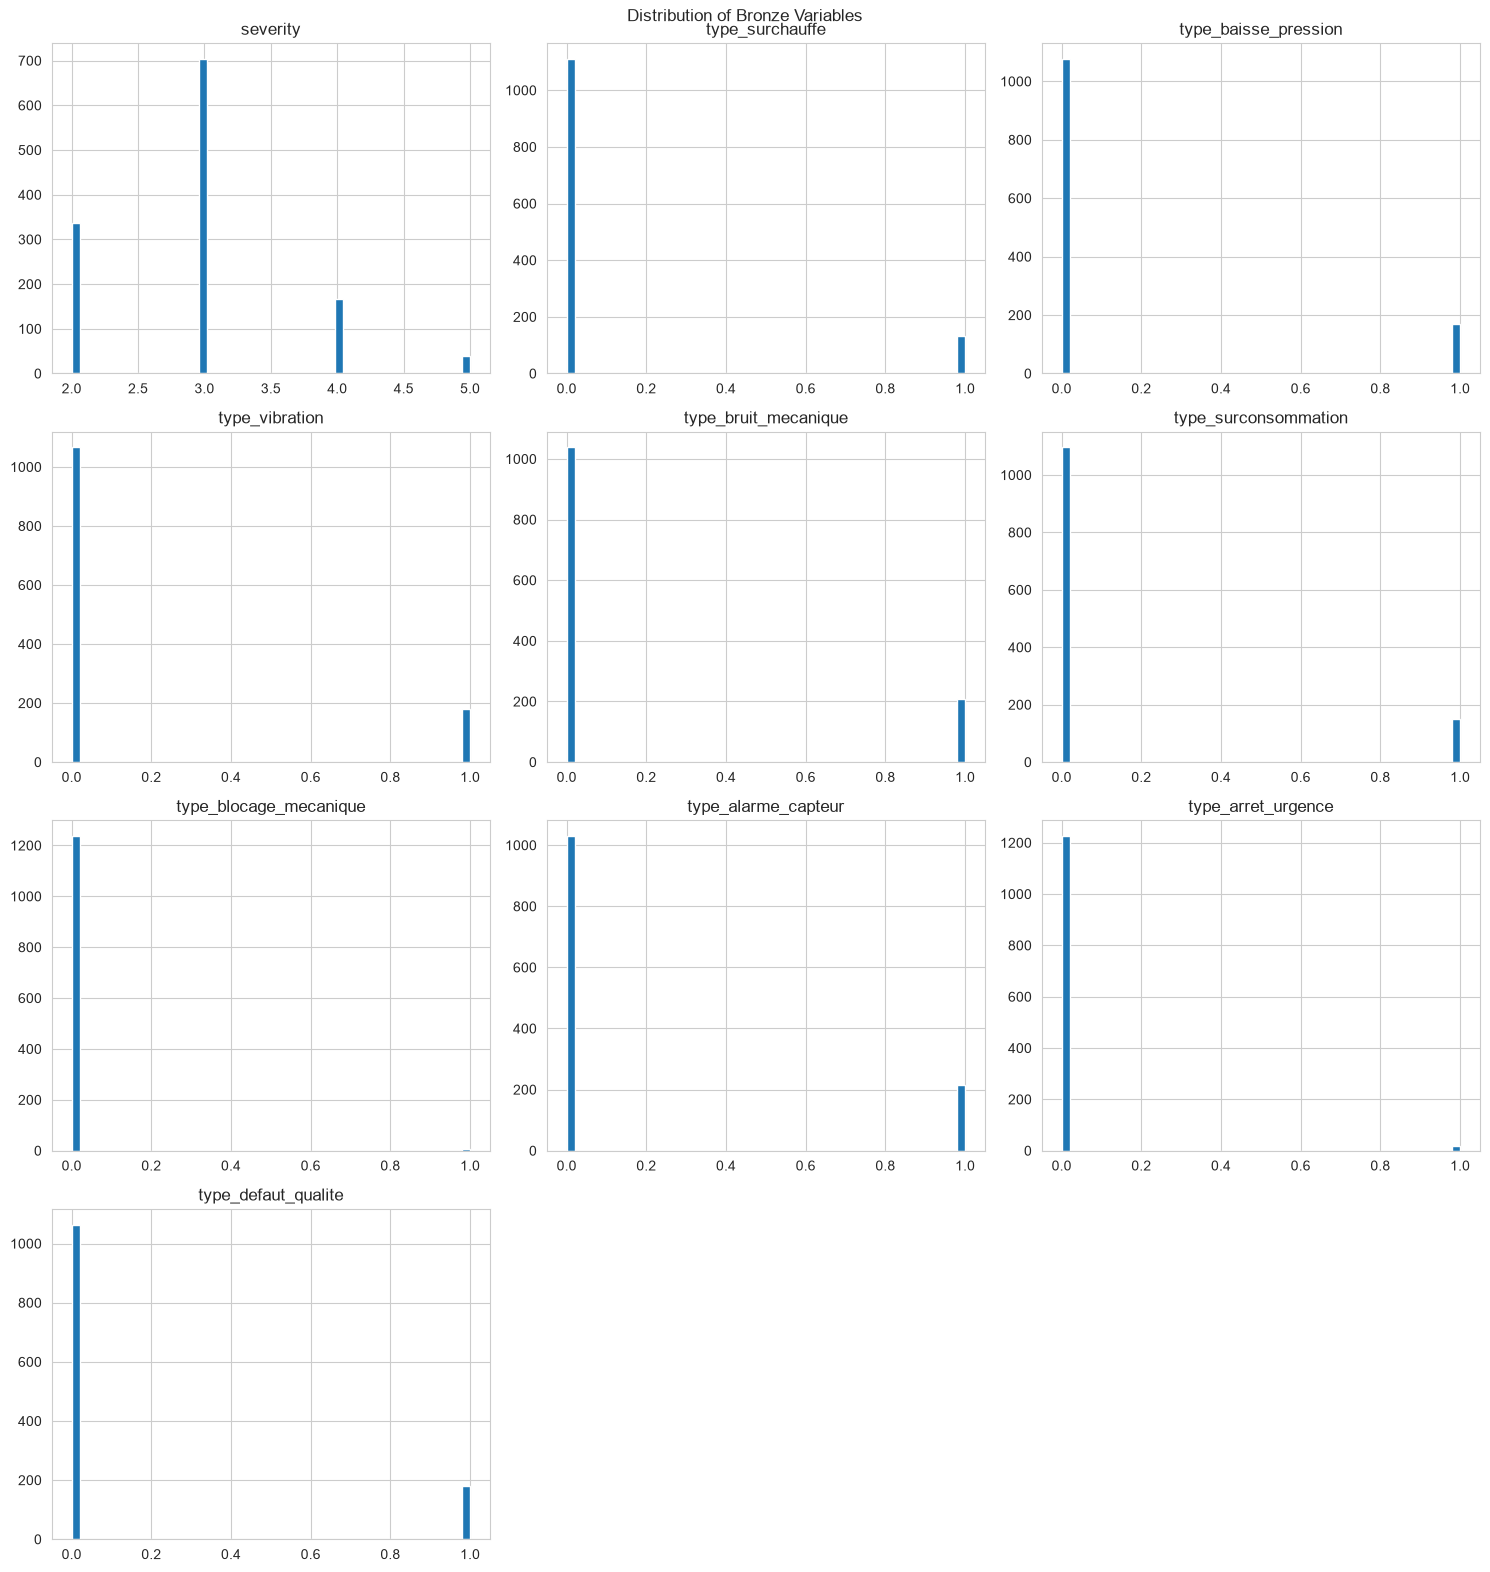

In [29]:
# Distribution of numeric variables
if numeric_cols:
    n_cols = len(numeric_cols)
    n_rows = (n_cols + 2) // 3
    
    bronze[numeric_cols].hist(bins=50, figsize=(15, n_rows*4), layout=(n_rows, 3))
    plt.suptitle('Distribution of Bronze Variables')
    plt.tight_layout()
    plt.savefig(run_dir / 'distribution_bronze.png', bbox_inches='tight', dpi=100)
    plt.show()

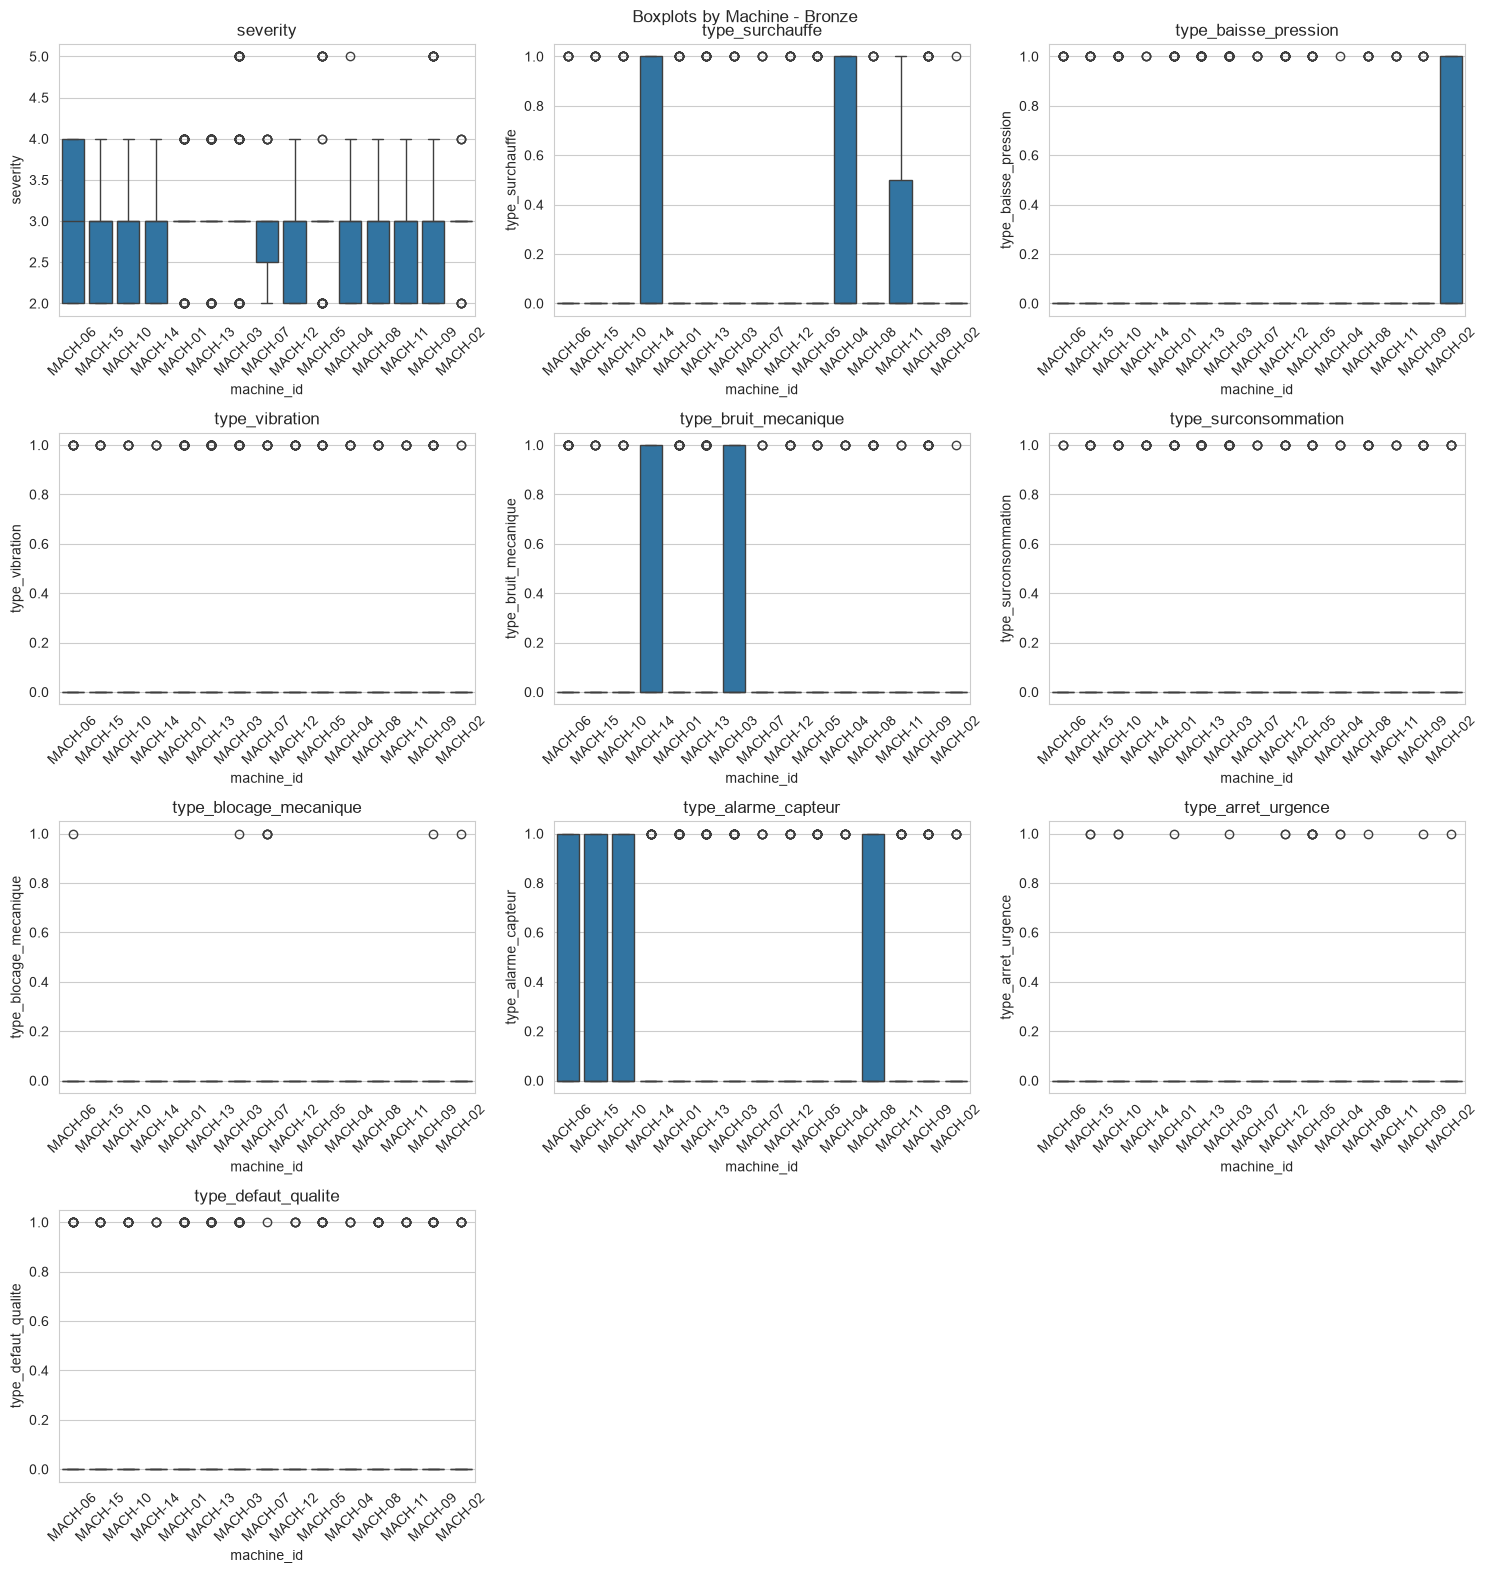

In [30]:
# Boxplots to detect outliers visually
if numeric_cols and 'machine_id' in bronze.columns:
    n_cols = len(numeric_cols)
    n_rows = (n_cols + 2) // 3
    
    fig, axes = plt.subplots(n_rows, 3, figsize=(15, n_rows*4))
    axes = axes.flatten()
    
    for i, col in enumerate(numeric_cols):
        sns.boxplot(data=bronze, x='machine_id', y=col, ax=axes[i])
        axes[i].set_title(col)
        axes[i].tick_params(axis='x', rotation=45)
    
    # Hide unused subplots
    for j in range(n_cols, len(axes)):
        axes[j].set_visible(False)
    
    plt.suptitle('Boxplots by Machine - Bronze')
    plt.tight_layout()
    plt.savefig(run_dir / 'boxplots_bronze.png', bbox_inches='tight', dpi=100)
    plt.show()

## 6. Detect and Handle Outliers Using IQR

In [31]:
# Detect outliers using IQR method
print("="*70)
print("OUTLIER DETECTION (IQR Method - 3*IQR bounds)")
print("="*70)

outlier_summary = {}

for col in numeric_cols:
    Q1 = bronze[col].quantile(0.25)
    Q3 = bronze[col].quantile(0.75)
    IQR = Q3 - Q1
    low = Q1 - 3 * IQR
    high = Q3 + 3 * IQR
    
    mask = (bronze[col] < low) | (bronze[col] > high)
    n_outliers = mask.sum()
    outlier_summary[col] = n_outliers
    
    print(f"{col:30s} → {n_outliers:4d} outliers (bounds: [{low:10.2f}, {high:10.2f}])")

print("="*70)
print(f"Total outliers in Bronze: {sum(outlier_summary.values())}")

OUTLIER DETECTION (IQR Method - 3*IQR bounds)
severity                       →    0 outliers (bounds: [     -1.00,       6.00])
type_surchauffe                →  134 outliers (bounds: [      0.00,       0.00])
type_baisse_pression           →  168 outliers (bounds: [      0.00,       0.00])
type_vibration                 →  179 outliers (bounds: [      0.00,       0.00])
type_bruit_mecanique           →  207 outliers (bounds: [      0.00,       0.00])
type_surconsommation           →  149 outliers (bounds: [      0.00,       0.00])
type_blocage_mecanique         →    8 outliers (bounds: [      0.00,       0.00])
type_alarme_capteur            →  215 outliers (bounds: [      0.00,       0.00])
type_arret_urgence             →   19 outliers (bounds: [      0.00,       0.00])
type_defaut_qualite            →  181 outliers (bounds: [      0.00,       0.00])
Total outliers in Bronze: 1260


## 7. Transform Bronze to Silver Layer

In [32]:
# Create silver layer
silver = bronze.copy()

# 1. Type conversion
if 'machine_id' in silver.columns:
    silver['machine_id'] = silver['machine_id'].astype('category')

# 2. Parse datetime if date/time columns exist
if 'date' in silver.columns and 'time' in silver.columns:
    silver['datetime'] = pd.to_datetime(silver['date'] + ' ' + silver['time'])
elif 'datetime' in silver.columns:
    silver['datetime'] = pd.to_datetime(silver['datetime'])
elif 'timestamp' in silver.columns:
    silver['timestamp'] = pd.to_datetime(silver['timestamp'])

# 3. Sort chronologically
datetime_col = None
if 'datetime' in silver.columns:
    datetime_col = 'datetime'
elif 'timestamp' in silver.columns:
    datetime_col = 'timestamp'

if datetime_col and 'machine_id' in silver.columns:
    silver = silver.sort_values(['machine_id', datetime_col]).reset_index(drop=True)

# 4. Temporal features
if datetime_col:
    silver['year'] = silver[datetime_col].dt.year
    silver['month'] = silver[datetime_col].dt.month
    silver['day'] = silver[datetime_col].dt.day
    silver['hour'] = silver[datetime_col].dt.hour
    silver['day_of_week'] = silver[datetime_col].dt.dayofweek
    silver['is_weekend'] = silver['day_of_week'].isin([5, 6])

# 5. Handle outliers - replace with NaN, then interpolate per machine
IQR_FACTOR = 3
outlier_report = {}

for col in numeric_cols:
    Q1 = silver[col].quantile(0.25)
    Q3 = silver[col].quantile(0.75)
    IQR = Q3 - Q1
    low = Q1 - IQR_FACTOR * IQR
    high = Q3 + IQR_FACTOR * IQR
    
    mask = (silver[col] < low) | (silver[col] > high)
    outlier_report[col] = int(mask.sum())
    silver.loc[mask, col] = np.nan

# 6. Linear interpolation per machine
if 'machine_id' in silver.columns:
    silver[numeric_cols] = (
        silver.groupby('machine_id', observed=True)[numeric_cols]
        .transform(lambda g: g.interpolate(method='linear', limit_direction='both'))
    )

# 7. Round numeric values
silver[numeric_cols] = silver[numeric_cols].round(2)

print(f"Silver shape: {silver.shape}")
print(f"NaN remaining: {silver.isna().sum().sum()}")
print(f"\nOutliers treated:")
for col, n in outlier_report.items():
    print(f"  {col}: {n}")

Silver shape: (1245, 25)
NaN remaining: 0

Outliers treated:
  severity: 0
  type_surchauffe: 134
  type_baisse_pression: 168
  type_vibration: 179
  type_bruit_mecanique: 207
  type_surconsommation: 149
  type_blocage_mecanique: 8
  type_alarme_capteur: 215
  type_arret_urgence: 19
  type_defaut_qualite: 181


In [33]:
# Export silver CSV
silver_output_path = run_dir / 'releves_incidents_silver.csv'
silver.to_csv(silver_output_path, index=False)

print(f"Silver layer exported to: {silver_output_path}")

Silver layer exported to: artifacts\ingestions\incidents\202606181716\releves_incidents_silver.csv


## 8. Compare Before and After Outlier Treatment

In [34]:
# Compare outlier counts
print("\n" + "="*70)
print("OUTLIER COMPARISON: BRONZE vs SILVER")
print("="*70)

print("\nBRONZE (before treatment):")
print("-"*70)
bronze_outliers = {}
for col in numeric_cols:
    Q1 = bronze[col].quantile(0.25)
    Q3 = bronze[col].quantile(0.75)
    IQR = Q3 - Q1
    low = Q1 - 3 * IQR
    high = Q3 + 3 * IQR
    n = ((bronze[col] < low) | (bronze[col] > high)).sum()
    bronze_outliers[col] = n
    print(f"{col:30s} → {n:6d} outliers")

print("\nSILVER (after interpolation):")
print("-"*70)
silver_outliers = {}
for col in numeric_cols:
    Q1 = silver[col].quantile(0.25)
    Q3 = silver[col].quantile(0.75)
    IQR = Q3 - Q1
    low = Q1 - 3 * IQR
    high = Q3 + 3 * IQR
    n = ((silver[col] < low) | (silver[col] > high)).sum()
    silver_outliers[col] = n
    print(f"{col:30s} → {n:6d} outliers")

print("\n" + "="*70)
total_bronze = sum(bronze_outliers.values())
total_silver = sum(silver_outliers.values())
reduction = total_bronze - total_silver

print(f"Total outliers BRONZE:    {total_bronze}")
print(f"Total outliers SILVER:    {total_silver}")
print(f"Outliers eliminated:      {reduction}")
print(f"Reduction percentage:     {100*reduction/total_bronze:.1f}%" if total_bronze > 0 else "N/A")
print("="*70)


OUTLIER COMPARISON: BRONZE vs SILVER

BRONZE (before treatment):
----------------------------------------------------------------------
severity                       →      0 outliers
type_surchauffe                →    134 outliers
type_baisse_pression           →    168 outliers
type_vibration                 →    179 outliers
type_bruit_mecanique           →    207 outliers
type_surconsommation           →    149 outliers
type_blocage_mecanique         →      8 outliers
type_alarme_capteur            →    215 outliers
type_arret_urgence             →     19 outliers
type_defaut_qualite            →    181 outliers

SILVER (after interpolation):
----------------------------------------------------------------------
severity                       →      0 outliers
type_surchauffe                →      0 outliers
type_baisse_pression           →      0 outliers
type_vibration                 →      0 outliers
type_bruit_mecanique           →      0 outliers
type_surconsommation      